# Analiza delnic
Na več načinov bom analiziral največjih 500-tih delnic na svetovnem trgu, na njih izvedel hitre Fourierove transformacije in primerjal kako se skupaj primerjajo z indexom S&P 500, ki naj bi posnemal njihovo obnašanje. <br>
Uporabljal bom podatke iz obdobja enega leta (od 1. julija 2025 do 1. julija 2026), ki sem jih pridobil iz strani Yahoo finance. <br>
Za podatke sem si izbral adjusted close price vseh delnic za vsak dan, ko je bila borza odprta, ter market cap, Beta marker in P/E razmerje vseh delnic 1.julija 2026, ko sem podatke pridobil s spleta.

In [14]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
from scipy.fft import fft, fftfreq

Izvedimo najprej Hitre Fourierove transformacije na indexu S&P 500:

In [53]:
CENE_SP_500 = pd.read_csv('SP_500_cene.csv')
CENE_SP_500_STOLPCI = CENE_SP_500.T.reset_index()
CENE_SP_500_STOLPCI.columns = ['Datum', 'Cena']
CENE_SP_500_STOLPCI = CENE_SP_500_STOLPCI.drop(0).reset_index(drop=True)
CENE_SP_500_STOLPCI['Cena'] = CENE_SP_500_STOLPCI['Cena'].str.replace(',', '')

CENE_SP_500_STOLPCI['Datum'] = pd.to_datetime(CENE_SP_500_STOLPCI['Datum'])
CENE_SP_500_STOLPCI['Cena'] = CENE_SP_500_STOLPCI['Cena'].astype(float)

#izračunamo razliko med podatki
CENE_SP_500_STOLPCI['Donos'] = CENE_SP_500_STOLPCI['Cena'].pct_change()

donosi_cisti = CENE_SP_500_STOLPCI['Donos'].dropna().values
stevilo_trgovalnih_dni = len(donosi_cisti)


fft_vrednosti = fft(donosi_cisti)
frekvence = fftfreq(stevilo_trgovalnih_dni, d=1)

# Jemljemo le pozitivne frekvence, saj je FFT vedmo simetričen
pozitivni_indeksi = frekvence > 0
f_prave = frekvence[pozitivni_indeksi]

#izračunamo moč posamezne frekvence
amplitude = np.abs(fft_vrednosti[pozitivni_indeksi])

#frekvence pretvorimo v periode: perioda = 1 / frekvenca
periode = 1 / f_prave


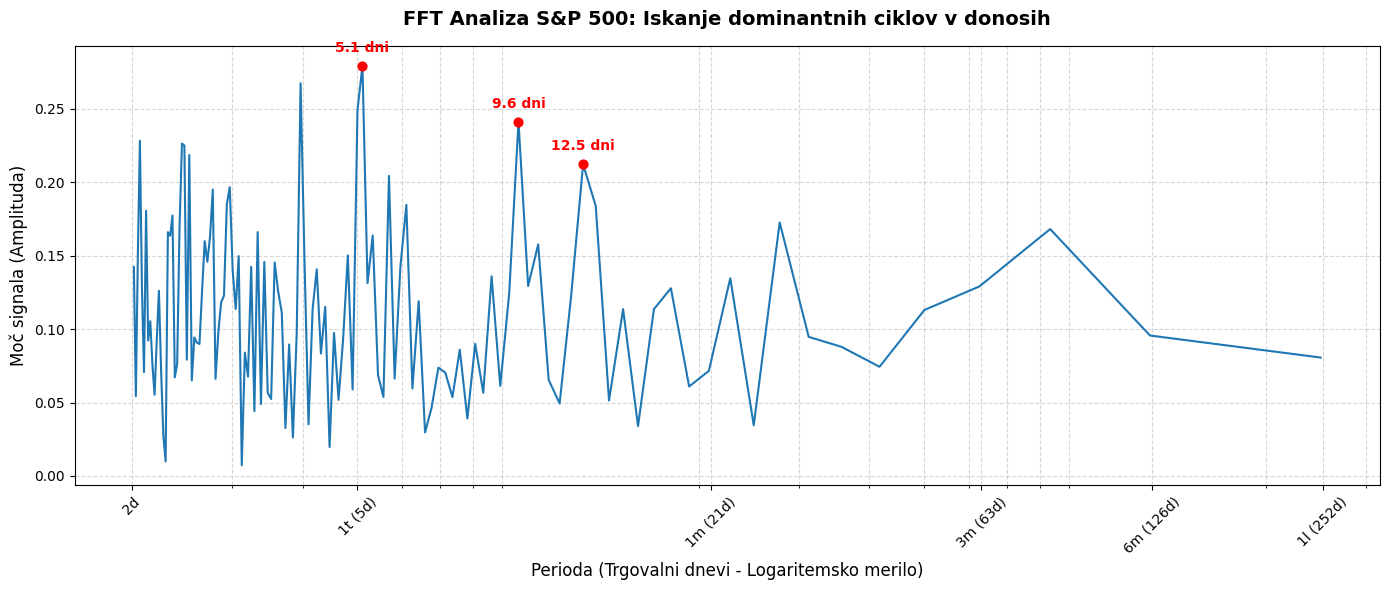

In [ ]:

plt.figure(figsize=(14, 6))

# Narišemo spekter (Perioda vs Amplituda)
plt.plot(periode, amplitude, color='#1f77b4', linewidth=1.5, label='FFT Amplituda')

# Ker so periode lahko zelo dolge (npr. 1000 dni) ali kratke (2 dni), 
# uporaba logaritemske osi X drastično izboljša preglednost.
plt.xscale('log')

# Dodajanje oznak za lažje branje (tipični borzni cikli)
# 5 dni = 1 teden, 21 dni = 1 mesec, 63 dni = 1 kvartal, 252 dni = 1 trgovalno leto
tipicni_cikli = [2, 5, 21, 63, 126, 252, 504]
oznake_ciklov = ['2d', '1t (5d)', '1m (21d)', '3m (63d)', '6m (126d)', '1l (252d)', '2l (504d)']

plt.xticks(tipicni_cikli, oznake_ciklov, rotation=45)

# Urejanje izgleda grafa
plt.title('FFT Analiza S&P 500: Iskanje dominantnih ciklov v donosih', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Perioda (Trgovalni dnevi - Logaritemsko merilo)', fontsize=12)
plt.ylabel('Moč signala (Amplituda)', fontsize=12)

# Vklop mreže za lažje odčitavanje
plt.grid(True, which="both", linestyle="--", alpha=0.5)

# Izpostavimo najmočnejše vršne vrednosti (top 3 vrhovi)
# (Omejimo iskanje vrhov na periode, daljše od 5 dni, da izločimo dnevni šum)
indeksi_nad_5d = periode > 5
if np.any(indeksi_nad_5d):
    najvisji_vrhovi = np.argsort(amplitude[indeksi_nad_5d])[-3:]
    for idx in najvisji_vrhovi:
        p_vrh = periode[indeksi_nad_5d][idx]
        a_vrh = amplitude[indeksi_nad_5d][idx]
        plt.scatter(p_vrh, a_vrh, color='red', s=40, zorder=5)
        plt.annotate(f"{p_vrh:.1f} dni", (p_vrh, a_vrh), textcoords="offset points", 
                     xytext=(0,10), ha='center', fontweight='bold', color='red')

plt.tight_layout()
plt.show()

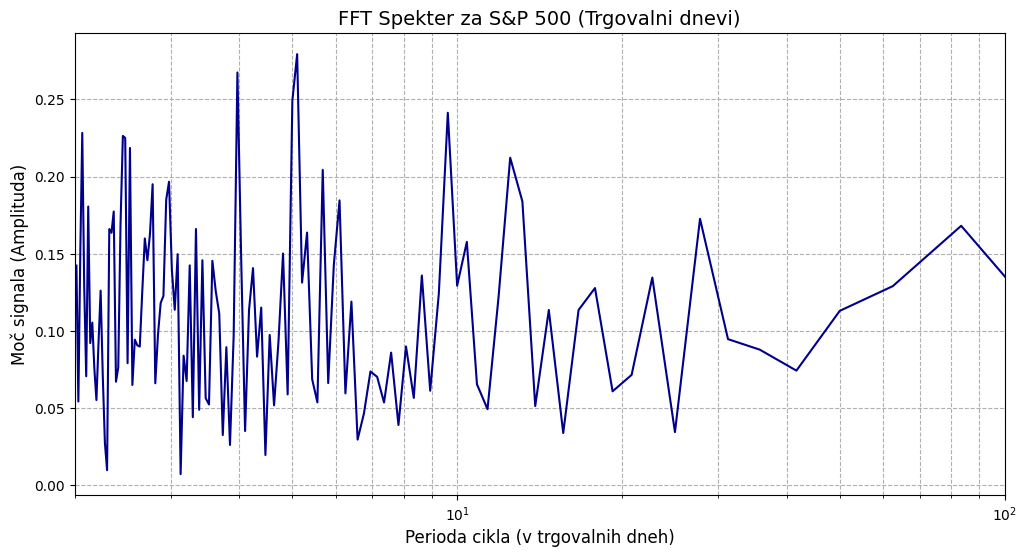

In [54]:
plt.figure(figsize=(12, 6))
plt.plot(periode, amplitude, color='darkblue', linewidth=1.5)
plt.xscale('log')
plt.title('FFT Spekter za S&P 500 (Trgovalni dnevi)', fontsize=14)
plt.xlabel('Perioda cikla (v trgovalnih dneh)', fontsize=12)
plt.ylabel('Moč signala (Amplituda)', fontsize=12)
plt.grid(True, which="both", ls="--")
plt.xlim(2, 100)

plt.show()

### Sledi Fourierova Extrapolacija indexa S&P 500:
Fourierova extrapolacija poteka v treh korakih in sicer:
1. izluščimo že znane podatke o ceni delnic
2. odstranimo trend (dolgoročno trg raste, zato ta trend izračunamo in odstranimo)
3. izvedemo FFT in poiščemo n najmočnejših frekvenc
4. ekstrapoliramo v prihodnost
5. združimo sedanje in prihodnje podatke ter prikažemo v grafu
